# Diabetes Prediction using Machine Learning

## Objective
Predict whether a patient is likely to have diabetes using machine learning algorithms.

## Dataset
Pima Indians Diabetes Dataset

## Models Used
- Logistic Regression
- Random Forest Classifier

## Libraries
- Pandas
- NumPy
- Scikit-Learn
- Matplotlib
- Seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


In [2]:
# Load Diabetes Dataset

diabetes_data = pd.read_csv(
    'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv',
    header=None,
    names=[
        'Pregnancies',
        'Glucose',
        'BloodPressure',
        'SkinThickness',
        'Insulin',
        'BMI',
        'DiabetesPedigree',
        'Age',
        'Outcome'
    ]
)

df = diabetes_data

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (768, 9)

First 5 Rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigree  Age  Outcome  
0             0.627   50        1  
1             0.351   31        0  
2             0.672   32        1  
3             0.167   21        0  
4             2.288   33        1  


In [3]:
print("\nMissing Values in Each Column:")
print(df.isnull().sum())
print("\\nMissing Values in Each Column:")
print(df.isnull().sum())



Missing Values in Each Column:
Pregnancies         0
Glucose             0
BloodPressure       0
SkinThickness       0
Insulin             0
BMI                 0
DiabetesPedigree    0
Age                 0
Outcome             0
dtype: int64
\nMissing Values in Each Column:
Pregnancies         0
Glucose             0
BloodPressure       0
SkinThickness       0
Insulin             0
BMI                 0
DiabetesPedigree    0
Age                 0
Outcome             0
dtype: int64


In [4]:
print("Dataset Statistics:")
print(df.describe())

print("\nOutcome Distribution:")
print(df['Outcome'].value_counts())

print(f"\nDiabetic Patients: {(df['Outcome']==1).sum()}")
print(f"Non-Diabetic Patients: {(df['Outcome']==0).sum()}")

Dataset Statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigree         Age     Outcome  
count  768.000000        768.000000  768.000000  768.000000  
mean    31.992578          0.471876   33.240885    0.348958  
std      7.884160          0.331329   11.760232    0.476951  
min      0.000000          0.078000   21.000000

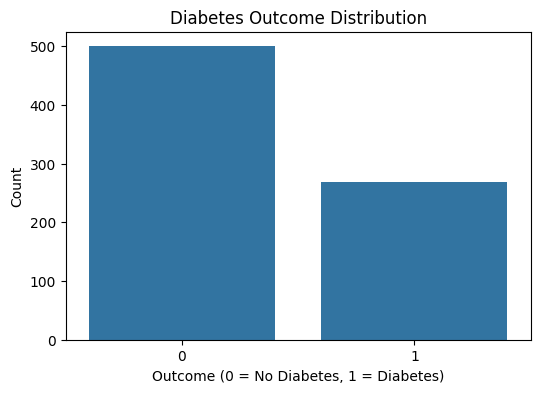

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(x='Outcome', data=df)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Count")

plt.show()

In [6]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (768, 8)
Target Shape: (768,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 614
Testing Samples: 154


### Model Training

Now that the data is split into training and testing sets, we can proceed to train a machine learning model. For this task, we will use a Logistic Regression model, which is a common and effective choice for binary classification problems like predicting diabetes.

In [8]:
# Initialize the Logistic Regression model
model = LogisticRegression(solver='liblinear', random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Completed!")

Scaling Completed!


In [10]:
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.7532467532467533


In [11]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7207792207792207


In [12]:
print("="*40)
print("MODEL COMPARISON")
print("="*40)

print("Logistic Regression:", lr_accuracy)
print("Random Forest:", rf_accuracy)

MODEL COMPARISON
Logistic Regression: 0.7532467532467533
Random Forest: 0.7207792207792207


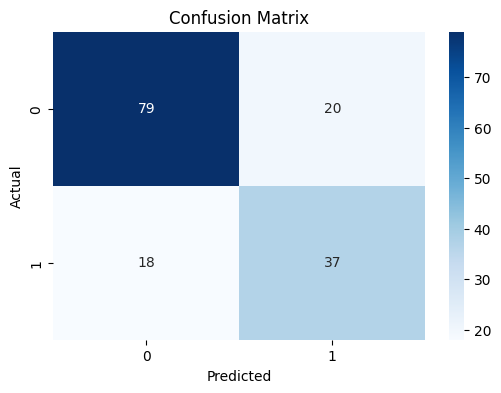

In [13]:
best_pred = lr_pred if lr_accuracy > rf_accuracy else rf_pred

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [14]:
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



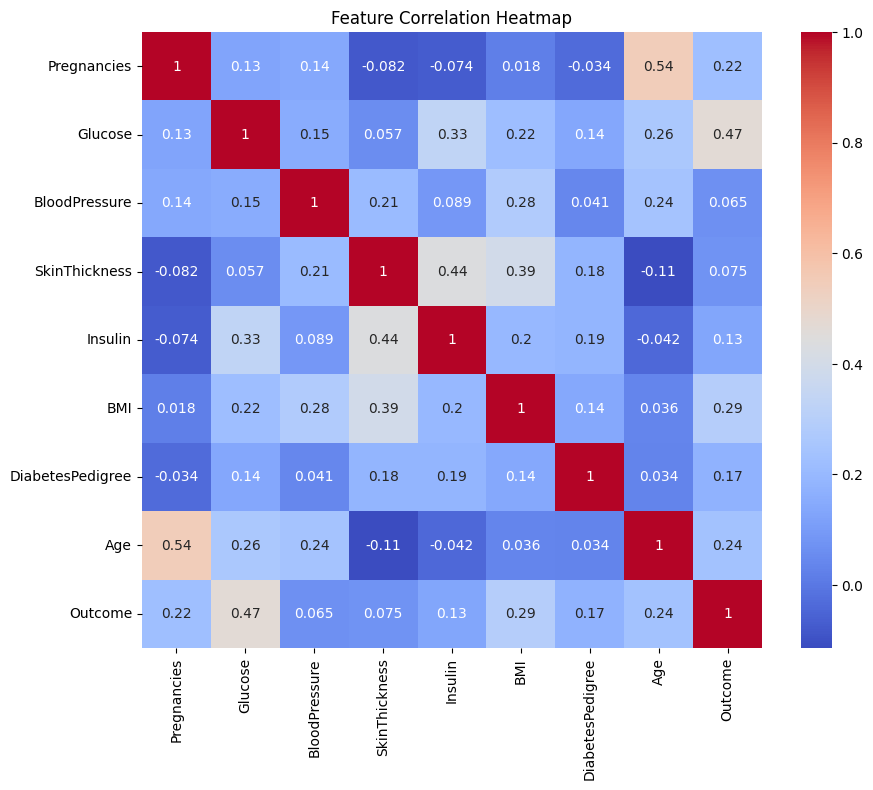

In [15]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
        annot=True,
            cmap="coolwarm"
            )

plt.title("Feature Correlation Heatmap")

plt.show()

In [16]:
sample_patient = pd.DataFrame({
    'Pregnancies':[2],
    'Glucose':[120],
    'BloodPressure':[70],
    'SkinThickness':[20],
    'Insulin':[80],
    'BMI':[28.5],
    'DiabetesPedigree':[0.5],
    'Age':[35]
})

sample_scaled = scaler.transform(sample_patient)

prediction = lr_model.predict(sample_scaled)[0]
probability = lr_model.predict_proba(sample_scaled)[0][1]

print("Prediction:", "Diabetic" if prediction == 1 else "Non-Diabetic")
print("Probability:", round(probability*100,2), "%")

Prediction: Non-Diabetic
Probability: 21.66 %


# Conclusion

- Logistic Regression achieved 75.32% accuracy.
- Random Forest achieved 72.08% accuracy.
- Logistic Regression performed better on this dataset.
- Feature analysis and visualizations were used to understand relationships between variables.

Future improvements:
- Hyperparameter tuning
- Cross-validation
- XGBoost implementation
- Explainable AI using SHAP